Detección de Anomalías, vamos a jugar a ser detectives de datos. En el mundo real, los errores humanos, los fraudes o las compras institucionales masivas pueden ensuciar nuestros análisis.

Vamos a usar un algoritmo fascinante llamado Isolation Forest (Bosque de Aislamiento). A diferencia de otros modelos que intentan aprender qué es lo "normal", este modelo se especializa en aislar rápidamente los datos "extraños". Le pediremos que busque el 1% de las transacciones más atípicas de nuestra base de datos.

1. Importar librerías de detección de anomalías

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")

# Conexión a la BD
load_dotenv('../.env')
engine = create_engine(f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}")

print("✅ Librerías cargadas y conectadas a la BD.")

C:\Users\Andres\AppData\Local\Temp\ipykernel_19232\738169242.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✅ Librerías cargadas y conectadas a la BD.


2. Extraer datos transaccionales

Vamos a traer todas las ventas para analizarlas. Nos interesan la cantidad comprada y el monto total pagado.

In [2]:
query = """
SELECT 
    v.id_venta,
    v.fecha,
    v.cantidad,
    p.precio_unitario,
    (v.cantidad * p.precio_unitario) AS total_venta
FROM ventas v
JOIN productos p ON v.id_producto = p.id_producto
WHERE v.estado = 'Completa';
"""

df_anomalias = pd.read_sql(query, engine)
print(f"Total de transacciones a analizar: {len(df_anomalias)}")
df_anomalias.head()

Total de transacciones a analizar: 2523


,id_venta,fecha,cantidad,precio_unitario,total_venta
0,919,2024-01-31,5,15.45,77.25
1,947,2024-01-31,1,5.65,5.65
2,1317,2024-01-31,3,15.45,46.35
3,1607,2024-01-31,5,3.51,17.55
4,2038,2024-01-31,5,5.21,26.05


3. Entrenar el Isolation Forest

El modelo analizará la relación entre la cantidad de productos que compra una persona y cuánto gasta.

In [3]:
# Variables a analizar
features = ['cantidad', 'total_venta']
X = df_anomalias[features]

# Inicializar modelo: contamination=0.01 significa que asumimos que el 1% de los datos son anomalías.
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# Entrenar y predecir
# El modelo devuelve -1 para anomalías y 1 para datos normales
predicciones = iso_forest.fit_predict(X)

# Transformamos esto a algo más lógico de negocio: 1 = Anomalía, 0 = Normal
df_anomalias['es_anomalia'] = np.where(predicciones == -1, 1, 0)

# anomaly_score: un número continuo que indica qué tan "raro" es el dato (menor puntaje = más raro)
df_anomalias['score_anomalia'] = iso_forest.decision_function(X)

# Ver cuántas anomalías encontró
resumen = df_anomalias['es_anomalia'].value_counts()
print(f"✅ Transacciones Normales: {resumen[0]}")
print(f"🚨 Anomalías Detectadas: {resumen[1]}")

✅ Transacciones Normales: 2507
🚨 Anomalías Detectadas: 16


4. Visualizar las Anomalías

Vamos a pintar las transacciones en un gráfico. Las normales estarán en gris o azul, y las anomalías brillarán en color rojo.

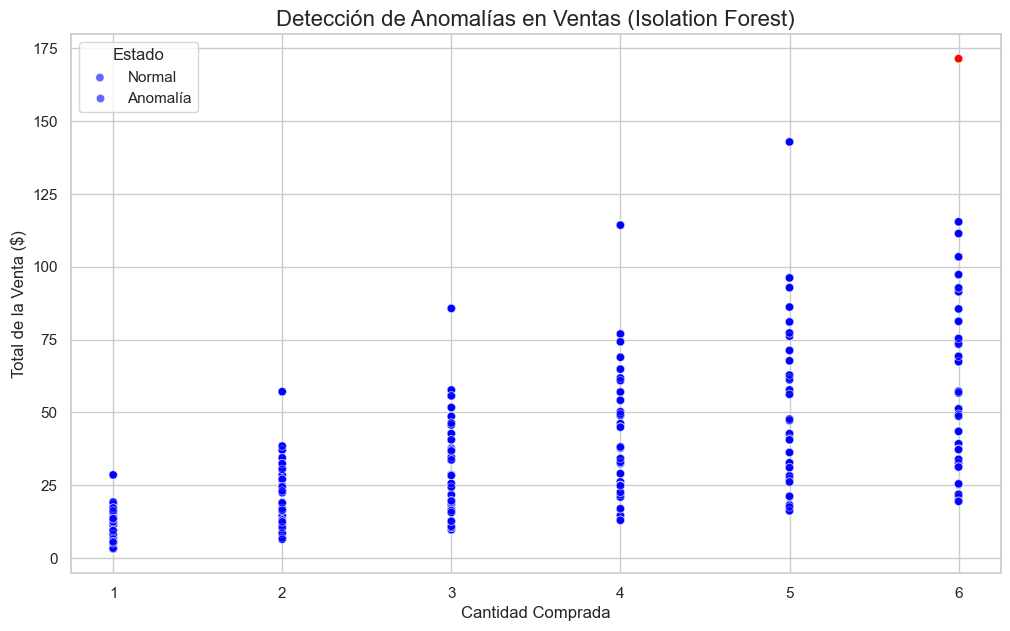

In [4]:
plt.figure(figsize=(12, 7))

# Gráfico de dispersión
sns.scatterplot(
    data=df_anomalias, 
    x='cantidad', 
    y='total_venta', 
    hue='es_anomalia', 
    palette={0: 'blue', 1: 'red'}, 
    alpha=0.6
)

plt.title('Detección de Anomalías en Ventas (Isolation Forest)', fontsize=16)
plt.xlabel('Cantidad Comprada', fontsize=12)
plt.ylabel('Total de la Venta ($)', fontsize=12)

# Modificar leyenda para que sea más clara
plt.legend(title='Estado', labels=['Normal', 'Anomalía'])
plt.show()

Interpretación: Verás que los puntos rojos probablemente estén en los bordes del gráfico. Estos pueden ser clientes mayoristas comprando cantidades masivas, o transacciones que tienen montos altísimos que se salen del estándar. Estas transacciones se apartan del análisis normal para que los ejecutivos las revisen.

5. Guardar resultados en PostgreSQL

Nuevamente, guardamos estos descubrimientos para mostrarlos después en nuestro Dashboard de Power BI.

In [5]:
print("📤 Guardando anomalías en PostgreSQL...")
try:
    # Seleccionamos solo las columnas importantes para la base de datos
    df_export = df_anomalias[['id_venta', 'es_anomalia', 'score_anomalia']]
    
    df_export.to_sql('anomalias_ventas', engine, if_exists='replace', index=False)
    
    with engine.connect() as con:
        con.execute(text("GRANT SELECT ON anomalias_ventas TO andes_user;"))
        con.commit()
        
    print("✅ ¡Anomalías guardadas con éxito en la tabla 'anomalias_ventas'!")
except Exception as e:
    print(f"❌ Error: {e}")

📤 Guardando anomalías en PostgreSQL...
✅ ¡Anomalías guardadas con éxito en la tabla 'anomalias_ventas'!
